# Training

This notebook builds the full training pipeline for TwinCar's car make/model/year
classifier and trains it end to end. It operates on Stanford Cars (16,103 images,
195 classes) using the split defined in `stanford_metadata.csv`.

Steps covered:
1. Copy images from the HuggingFace cache into ImageFolder structure
2. Verify split integrity
3. Define augmentation and build DataLoaders with class-balance sampling
4. Load and configure EfficientNet-B0 for single-phase full fine-tuning
5. Train with ReduceLROnPlateau, mixed precision, and early stopping
6. Save the best model and plot training curves

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import json

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

from datasets import load_dataset

PROJECT_DIR = Path("/content/drive/MyDrive/twincar")  # Drive project folder
DATA_DIR = Path("/content/twincar_data")              # local Colab storage for copied images

METADATA_PATH = PROJECT_DIR / "data" / "stanford_metadata.csv"
STANFORD_CACHE = PROJECT_DIR / "stanford_cars_cache"

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("METADATA_PATH exists:", METADATA_PATH.exists())
print("STANFORD_CACHE:", STANFORD_CACHE)
print("MODEL_DIR:", MODEL_DIR)

assert PROJECT_DIR.exists(), "PROJECT_DIR does not exist. Check Google Drive mount."
assert METADATA_PATH.exists(), "stanford_metadata.csv not found. Run 02_data_preparation first."

PROJECT_DIR: /content/drive/MyDrive/twincar
DATA_DIR: /content/twincar_data
METADATA_PATH exists: True
STANFORD_CACHE: /content/drive/MyDrive/twincar/stanford_cars_cache
MODEL_DIR: /content/drive/MyDrive/twincar/models


## Folder Structure Strategy

We copy images from the HuggingFace cache into a directory tree that matches
PyTorch's `ImageFolder` convention:

    data/
      train/
        AM_General_Hummer_SUV_2000/
        Acura_Integra_Type_R_2001/
        ...
      val/
        ...
      test/
        ...

`ImageFolder` auto-assigns labels from subfolder names, which means:
- No custom Dataset class needed
- Fully compatible with torchvision pipelines
- Easy to inspect on disk during debugging

Class names are sanitized (spaces -> underscores, slashes removed) to be
filesystem-safe. The label integer from `stanford_metadata.csv` is NOT used
directly - `ImageFolder` will re-assign 0-indexed integers alphabetically,
which is consistent and reproducible.

In [ ]:
metadata = pd.read_csv(METADATA_PATH)

def sanitize(name):
    return name.replace(" ", "_").replace("/", "-")

def reset_split_dirs():
    """
    Remove old ImageFolder split directories so previous runs
    do not leave stale images inside train/val/test.
    """
    for split_name in ["train", "val", "test"]:
        split_dir = Path(DATA_DIR) / split_name

        if split_dir.exists():
            shutil.rmtree(split_dir)

        split_dir.mkdir(parents=True, exist_ok=True)

    print("Old train/val/test folders cleared.")

def get_class_name(row):
    """
    Use class_name if available, otherwise fallback to car_name.
    """
    if "class_name" in row and pd.notna(row["class_name"]):
        return row["class_name"]
    return row["car_name"]

def copy_split(dataset_hf, df_split, split_name):
    split_dir = Path(DATA_DIR) / split_name
    copied = 0

    for _, row in df_split.iterrows():
        class_name = get_class_name(row)
        class_dir = split_dir / sanitize(class_name)
        class_dir.mkdir(parents=True, exist_ok=True)

        out_path = class_dir / f"{int(row['hf_idx'])}.jpg"

        img = dataset_hf[int(row["hf_idx"])]["image_path"]
        img.save(out_path)

        copied += 1

    print(f"{split_name}: {copied} images copied")

dataset = load_dataset("naufalso/stanford_cars", cache_dir=STANFORD_CACHE)

train_df = metadata[metadata["split"] == "train"].reset_index(drop=True)
val_df   = metadata[metadata["split"] == "val"].reset_index(drop=True)
test_df  = metadata[metadata["split"] == "test"].reset_index(drop=True)

reset_split_dirs()

copy_split(dataset["train"], train_df, "train")
copy_split(dataset["train"], val_df,   "val")
copy_split(dataset["test"],  test_df,  "test")

del dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

Old train/val/test folders cleared.
train: 6887 images copied
val: 1216 images copied
test: 8000 images copied


In [ ]:
EXPECTED_CLASSES = 195

expected_counts = {
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df)
}

for split in ["train", "val", "test"]:
    split_path = Path(DATA_DIR) / split
    classes = sorted(os.listdir(split_path))

    total_imgs = sum(
        len(list((split_path / c).glob("*.jpg")))
        for c in classes
    )

    print(f"{split}: {len(classes)} classes, {total_imgs} images")

    assert len(classes) == EXPECTED_CLASSES, f"{split} should have {EXPECTED_CLASSES} classes"
    assert total_imgs == expected_counts[split], (
        f"{split} should have {expected_counts[split]} images, but found {total_imgs}"
    )

print("Folder verification passed.")

train: 195 classes, 6887 images
val: 195 classes, 1216 images
test: 195 classes, 8000 images
Folder verification passed.


## Augmentation Strategy

Stanford Cars contains relatively clean public car images, while the real TwinCar use case may include more variation from drones and ground robots.

The production images may contain:

- different camera angles
- lighting changes
- shadows and reflections
- different vehicle scale in the image
- small camera tilt

For the first baseline, we use conservative augmentation. The goal is to make the model more robust without destroying important make/model details such as headlights, grille shape, rear lights, and body shape.

| Transform | Purpose |
|---|---|
| `RandomResizedCrop(224, scale=0.8–1.0)` | Simulates small scale and crop variation |
| `RandomHorizontalFlip(p=0.5)` | Handles left/right vehicle direction |
| `RandomRotation(10°)` | Simulates small camera tilt |
| `ColorJitter(0.2, 0.2, 0.1, 0.02)` | Simulates moderate lighting and color variation |

Validation and test images use deterministic preprocessing only. No random augmentation is applied to validation or test data, because we want stable and fair evaluation metrics.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Handling Class Imbalance

The EDA found class counts ranging from 24 to 68 images - a ~2.8× ratio.
While not extreme, with only ~35 images/class on average, the majority classes
can still dominate gradient updates during early training.

We use `WeightedRandomSampler` rather than weighted loss for the following reason:
sampler-based oversampling ensures every batch sees a balanced class distribution,
which stabilizes gradient variance early in training. Weighted loss is complementary
but acts more softly — it scales gradients rather than guaranteeing exposure.

For a mild imbalance like ours, the sampler alone is sufficient.

In [ ]:
train_dataset = datasets.ImageFolder(f'{DATA_DIR}/train', transform=train_transforms)
val_dataset   = datasets.ImageFolder(f'{DATA_DIR}/val',   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(f'{DATA_DIR}/test',  transform=val_test_transforms)

targets = train_dataset.targets

class_counts = Counter(targets)

class_weights = {
    class_id: 1.0 / count
    for class_id, count in class_counts.items()
}

sample_weights = [
    class_weights[target]
    for target in targets
]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Sampler created.")
print("Number of training samples:", len(sample_weights))
print("Number of classes:", len(class_counts))


Sampler created.
Number of training samples: 6887
Number of classes: 195


In [ ]:
# Safety check: ImageFolder must use the same class-to-index mapping
# for train, validation, and test.
assert train_dataset.class_to_idx == val_dataset.class_to_idx, "Train and val class mapping mismatch!"
assert train_dataset.class_to_idx == test_dataset.class_to_idx, "Train and test class mapping mismatch!"

print("ImageFolder class mappings are consistent across train/val/test.")

# Save mapping from model output index to ImageFolder class name.
# Example: 42 -> "BMW_X5_SUV_2007"
idx_to_class = {
    idx: class_name
    for class_name, idx in train_dataset.class_to_idx.items()
}

# Save locally for this runtime
local_label_map_path = DATA_DIR / "imagefolder_label_map.json"

with open(local_label_map_path, "w") as f:
    json.dump(idx_to_class, f, indent=4)

# Save permanently to Google Drive
drive_label_map_path = PROJECT_DIR / "data" / "imagefolder_label_map.json"

with open(drive_label_map_path, "w") as f:
    json.dump(idx_to_class, f, indent=4)

print("Saved local ImageFolder label map to:", local_label_map_path)
print("Saved Drive ImageFolder label map to:", drive_label_map_path)

ImageFolder class mappings are consistent across train/val/test.
Saved local ImageFolder label map to: /content/twincar_data/imagefolder_label_map.json
Saved Drive ImageFolder label map to: /content/drive/MyDrive/twincar/data/imagefolder_label_map.json


In [ ]:
NUM_WORKERS = 2 if os.cpu_count() > 1 else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Classes       : {len(train_dataset.classes)}')

Train batches : 216
Val batches   : 38
Test batches  : 250
Classes       : 195


## Model: EfficientNet-B0

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

torch.backends.cudnn.benchmark = True

Device: cuda


In [ ]:
NUM_CLASSES = len(train_dataset.classes)  # 195

model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Replace classifier head
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)
)

# Single-phase: the entire network is trainable from the start (no freezing)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]


Trainable params: 4,257,343 / 4,257,343


## Save Config to Drive

All hyperparameters are saved to `train_config.json` so the evaluation notebook
has a single source of truth for image size, batch size, and class count.

In [ ]:
import json

EPOCHS       = 30          # upper bound; early stopping usually ends sooner
LR           = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 5           # epochs without val-loss improvement before stopping
LR_PATIENCE  = 2           # epochs without improvement before LR is halved

train_config = {
    "model":           "efficientnet_b0",
    "num_classes":     NUM_CLASSES,
    "img_size":        IMG_SIZE,
    "batch_size":      BATCH_SIZE,
    "seed":            SEED,
    "epochs":          EPOCHS,
    "lr":              LR,
    "weight_decay":    WEIGHT_DECAY,
    "patience":        PATIENCE,
    "lr_patience":     LR_PATIENCE,
    "label_smoothing": 0.1,
    "dropout":         0.3,
    "imagenet_mean":   IMAGENET_MEAN,
    "imagenet_std":    IMAGENET_STD,
}

config_path = MODEL_DIR / "train_config.json"
with open(config_path, "w") as f:
    json.dump(train_config, f, indent=4)

print("Saved train_config.json to:", config_path)

Saved train_config.json to: /content/drive/MyDrive/twincar/models/train_config.json


## Loss, Optimizer, Scheduler

- **Loss**: cross-entropy with label smoothing (0.1) - discourages over-confident
  predictions, which helps on fine-grained classes.
- **Optimizer**: AdamW over *all* parameters at `lr=3e-4`.
- **Scheduler**: `ReduceLROnPlateau` watches validation loss and halves the LR
  after `LR_PATIENCE` epochs without improvement. Unlike a fixed cosine schedule,
  it never decays the LR while the model is still learning.

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=train_config["label_smoothing"])

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE
)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

print("Loss, optimizer, scheduler, and AMP scaler ready.")

Loss, optimizer, scheduler, and AMP scaler ready.


## Training Helpers

In [ ]:
import time

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss   = 0.0
    correct_top1 = 0
    correct_top5 = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct_top1 += (logits.argmax(1) == labels).sum().item()
        _, p5 = logits.topk(5, dim=1)
        correct_top5 += (p5 == labels.unsqueeze(1)).any(1).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct_top1 / n, correct_top5 / n


def save_checkpoint(path, epoch, model, optimizer, scheduler, history, best_val_loss):
    torch.save(
        {
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history":              history,
            "best_val_loss":        best_val_loss,
        },
        path,
    )


print("Helper functions defined.")

Helper functions defined.


## Training Loop

In [ ]:
history = {
    "train_loss": [], "val_loss": [],
    "train_top1": [], "val_top1": [], "val_top5": [],
    "lr":         [],
}

best_val_loss  = float("inf")
best_ckpt_path = MODEL_DIR / "best_model.pt"
wait = 0

print("=" * 64)
print("TRAINING — full fine-tuning with ReduceLROnPlateau + early stopping")
print("=" * 64)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_top1, _ = run_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_top1, val_top5 = run_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_top1"].append(train_top1)
    history["val_top1"].append(val_top1)
    history["val_top5"].append(val_top5)
    history["lr"].append(current_lr)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"| train_loss {train_loss:.4f} "
        f"| val_loss {val_loss:.4f} "
        f"| top1 {val_top1:.3f} "
        f"| top5 {val_top5:.3f} "
        f"| lr {current_lr:.2e} "
        f"| {elapsed:.0f}s"
    )

    save_checkpoint(MODEL_DIR / "last_checkpoint.pt", epoch, model, optimizer, scheduler, history, best_val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), best_ckpt_path)
        print(f"  -> val loss improved to {best_val_loss:.4f} — saved best_model.pt (top1 {val_top1:.3f})")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no val-loss improvement for {PATIENCE} epochs).")
            break

best_idx = int(np.argmin(history["val_loss"]))
print()
print(f"Training complete. Best epoch: {best_idx + 1} "
      f"| val_loss {history['val_loss'][best_idx]:.4f} "
      f"| val top1 {history['val_top1'][best_idx]:.3f} "
      f"| val top5 {history['val_top5'][best_idx]:.3f}")

TRAINING — full fine-tuning with ReduceLROnPlateau + early stopping
Epoch 01/30 | train_loss 4.6576 | val_loss 3.7768 | top1 0.233 | top5 0.546 | lr 3.00e-04 | 212s
  -> val loss improved to 3.7768 — saved best_model.pt (top1 0.233)
Epoch 02/30 | train_loss 2.8229 | val_loss 2.5803 | top1 0.514 | top5 0.813 | lr 3.00e-04 | 98s
  -> val loss improved to 2.5803 — saved best_model.pt (top1 0.514)
Epoch 03/30 | train_loss 1.9150 | val_loss 2.1174 | top1 0.658 | top5 0.882 | lr 3.00e-04 | 96s
  -> val loss improved to 2.1174 — saved best_model.pt (top1 0.658)
Epoch 04/30 | train_loss 1.5698 | val_loss 1.9429 | top1 0.698 | top5 0.910 | lr 3.00e-04 | 101s
  -> val loss improved to 1.9429 — saved best_model.pt (top1 0.698)
Epoch 05/30 | train_loss 1.3558 | val_loss 1.8966 | top1 0.706 | top5 0.914 | lr 3.00e-04 | 99s
  -> val loss improved to 1.8966 — saved best_model.pt (top1 0.706)
Epoch 06/30 | train_loss 1.2743 | val_loss 1.8665 | top1 0.708 | top5 0.927 | lr 3.00e-04 | 100s
  -> val loss

## Training Curves

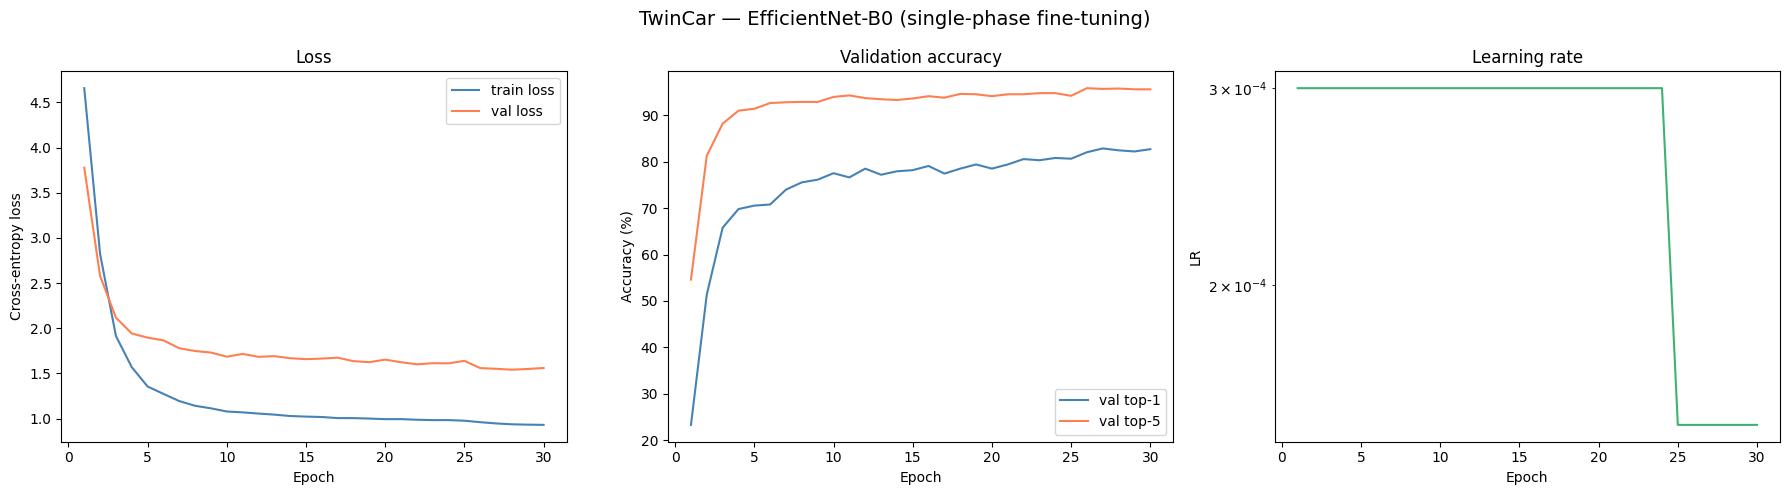

Saved training curves to: /content/drive/MyDrive/twincar/models/training_curves.png


In [ ]:
import matplotlib.pyplot as plt

n_epochs = len(history["train_loss"])
epochs_axis = list(range(1, n_epochs + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(epochs_axis, history["train_loss"], label="train loss", color="steelblue")
ax.plot(epochs_axis, history["val_loss"],   label="val loss",   color="coral")
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.legend()

ax = axes[1]
ax.plot(epochs_axis, [v * 100 for v in history["val_top1"]], label="val top-1", color="steelblue")
ax.plot(epochs_axis, [v * 100 for v in history["val_top5"]], label="val top-5", color="coral")
ax.set_title("Validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()

ax = axes[2]
ax.plot(epochs_axis, history["lr"], color="mediumseagreen")
ax.set_title("Learning rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("LR")
ax.set_yscale("log")

plt.suptitle("TwinCar — EfficientNet-B0 (single-phase fine-tuning)", fontsize=14)
plt.tight_layout()

curves_path = MODEL_DIR / "training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print("Saved training curves to:", curves_path)

## Summary

Files saved to Google Drive:

| File | Description |
|---|---|
| `models/best_model.pt` | State dict of the lowest-val-loss epoch |
| `models/last_checkpoint.pt` | Full resumable checkpoint (last epoch) |
| `models/train_config.json` | All hyperparameters |
| `models/training_curves.png` | Loss, accuracy, and LR plots |

**Next step:** `05_evaluation.ipynb` — load `best_model.pt`, run inference on the
held-out test split, and compute top-1/top-5, per-make F1, and the confusion matrix.

In [ ]:
print("Files on Drive:")
for f in sorted(MODEL_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name:40s} {f.stat().st_size/1e6:.1f} MB")

best_idx = int(np.argmin(history["val_loss"]))
print()
print(f"Best epoch     : {best_idx + 1}")
print(f"Best val top-1 : {history['val_top1'][best_idx]*100:.2f}%")
print(f"Best val top-5 : {history['val_top5'][best_idx]*100:.2f}%")

Files on Drive:
  best_model.pt                            17.3 MB
  confused_pairs_efficientnet_b0.csv       0.0 MB
  confusion_matrix_efficientnet_b0.png     0.2 MB
  last_checkpoint.pt                       51.6 MB
  per_make_metrics_efficientnet_b0.csv     0.0 MB
  setup_checkpoint.pt                      17.3 MB
  train_config.json                        0.0 MB
  training_curves.png                      0.1 MB

Best epoch     : 28
Best val top-1 : 82.48%
Best val top-5 : 95.81%
